In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time, os, joblib, warnings
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from sklearn.utils import resample
from scipy.stats import uniform, randint, loguniform

warnings.filterwarnings('ignore')

In [17]:
cols_pima = ['Pregnancies','Glucose','BloodPressure','SkinThickness',
             'Insulin','BMI','DiabetesPedigree','Age','Outcome']
df1 = pd.read_csv("https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv",
                   header=None, names=cols_pima)
print(df1.shape)
df1.head()

(768, 9)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigree,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [18]:
cols_heart = ['age','sex','cp','trestbps','chol','fbs','restecg',
              'thalach','exang','oldpeak','slope','ca','thal','target']
df2 = pd.read_csv("https://archive.ics.uci.edu/ml/machine-learning-databases/heart-disease/processed.cleveland.data",
                   header=None, names=cols_heart, na_values='?')
df2['target'] = (df2['target'] > 0).astype(int)
print(df2.shape)
df2.head()

(303, 14)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,1
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0


## 1. Структура данных


In [19]:
print("=== Pima ===")
print(df1.info())
print(df1.describe())
print("\n=== Heart ===")
print(df2.info())
print(df2.describe())

=== Pima ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Pregnancies       768 non-null    int64  
 1   Glucose           768 non-null    int64  
 2   BloodPressure     768 non-null    int64  
 3   SkinThickness     768 non-null    int64  
 4   Insulin           768 non-null    int64  
 5   BMI               768 non-null    float64
 6   DiabetesPedigree  768 non-null    float64
 7   Age               768 non-null    int64  
 8   Outcome           768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB
None
       Pregnancies     Glucose  BloodPressure  SkinThickness     Insulin  \
count   768.000000  768.000000     768.000000     768.000000  768.000000   
mean      3.845052  120.894531      69.105469      20.536458   79.799479   
std       3.369578   31.972618      19.355807      15.952218  115.244002   
min   

## 2. Предобработка

In [20]:
df1_clean = df1.copy()
for c in ['Glucose','BloodPressure','SkinThickness','Insulin','BMI']:
    med = df1_clean[c][df1_clean[c] != 0].median()
    df1_clean[c] = df1_clean[c].replace(0, med)

X1 = df1_clean.drop('Outcome', axis=1)
y1 = df1_clean['Outcome']
print("Pima классы:", y1.value_counts().to_dict())

Pima классы: {0: 500, 1: 268}


In [21]:
df2_clean = df2.fillna(df2.median())
X2 = df2_clean.drop('target', axis=1)
y2 = df2_clean['target']
print("Heart классы:", y2.value_counts().to_dict())

Heart классы: {0: 164, 1: 139}


## 3–4. Train/test split + масштабирование

In [22]:
X1_tr, X1_te, y1_tr, y1_te = train_test_split(X1, y1, test_size=0.2, random_state=42, stratify=y1)
X2_tr, X2_te, y2_tr, y2_te = train_test_split(X2, y2, test_size=0.2, random_state=42, stratify=y2)

sc1 = StandardScaler()
X1_tr_s = sc1.fit_transform(X1_tr)
X1_te_s = sc1.transform(X1_te)

sc2 = StandardScaler()
X2_tr_s = sc2.fit_transform(X2_tr)
X2_te_s = sc2.transform(X2_te)

print(f"Pima train/test: {X1_tr_s.shape} / {X1_te_s.shape}")
print(f"Heart train/test: {X2_tr_s.shape} / {X2_te_s.shape}")

Pima train/test: (614, 8) / (154, 8)
Heart train/test: (242, 13) / (61, 13)


## 5. Обучение моделей

In [23]:
models = {
    'LogReg': LogisticRegression(max_iter=1000, random_state=42),
    'SVM': SVC(random_state=42),
    'RF': RandomForestClassifier(n_estimators=100, random_state=42),
    'GBM': GradientBoostingClassifier(n_estimators=100, random_state=42),
    'NB': GaussianNB(),
    'KNN': KNeighborsClassifier(n_neighbors=5)
}

In [24]:
def run_models(X_tr, X_te, y_tr, y_te, label):
    print(f"\n{label}:\n")
    res = {}
    for name, m in models.items():
        t0 = time.time()
        m.fit(X_tr, y_tr)
        t_train = time.time() - t0

        t0 = time.time()
        yp = m.predict(X_te)
        t_pred = time.time() - t0

        acc = accuracy_score(y_te, yp)
        print(f"\n{name}: acc={acc:.4f} (train {t_train:.3f}s, pred {t_pred:.4f}s)")
        print(classification_report(y_te, yp))

        res[name] = {'acc': acc, 'pred': yp, 't_train': t_train, 't_pred': t_pred}
    return res

res1 = run_models(X1_tr_s, X1_te_s, y1_tr, y1_te, "PIMA")
res2 = run_models(X2_tr_s, X2_te_s, y2_tr, y2_te, "HEART")


PIMA:


LogReg: acc=0.7078 (train 0.031s, pred 0.0005s)
              precision    recall  f1-score   support

           0       0.75      0.82      0.78       100
           1       0.60      0.50      0.55        54

    accuracy                           0.71       154
   macro avg       0.68      0.66      0.67       154
weighted avg       0.70      0.71      0.70       154


SVM: acc=0.7403 (train 0.042s, pred 0.0122s)
              precision    recall  f1-score   support

           0       0.78      0.84      0.81       100
           1       0.65      0.56      0.60        54

    accuracy                           0.74       154
   macro avg       0.71      0.70      0.70       154
weighted avg       0.73      0.74      0.73       154


RF: acc=0.7792 (train 0.390s, pred 0.0159s)
              precision    recall  f1-score   support

           0       0.81      0.87      0.84       100
           1       0.72      0.61      0.66        54

    accuracy                      

## Confusion matrices


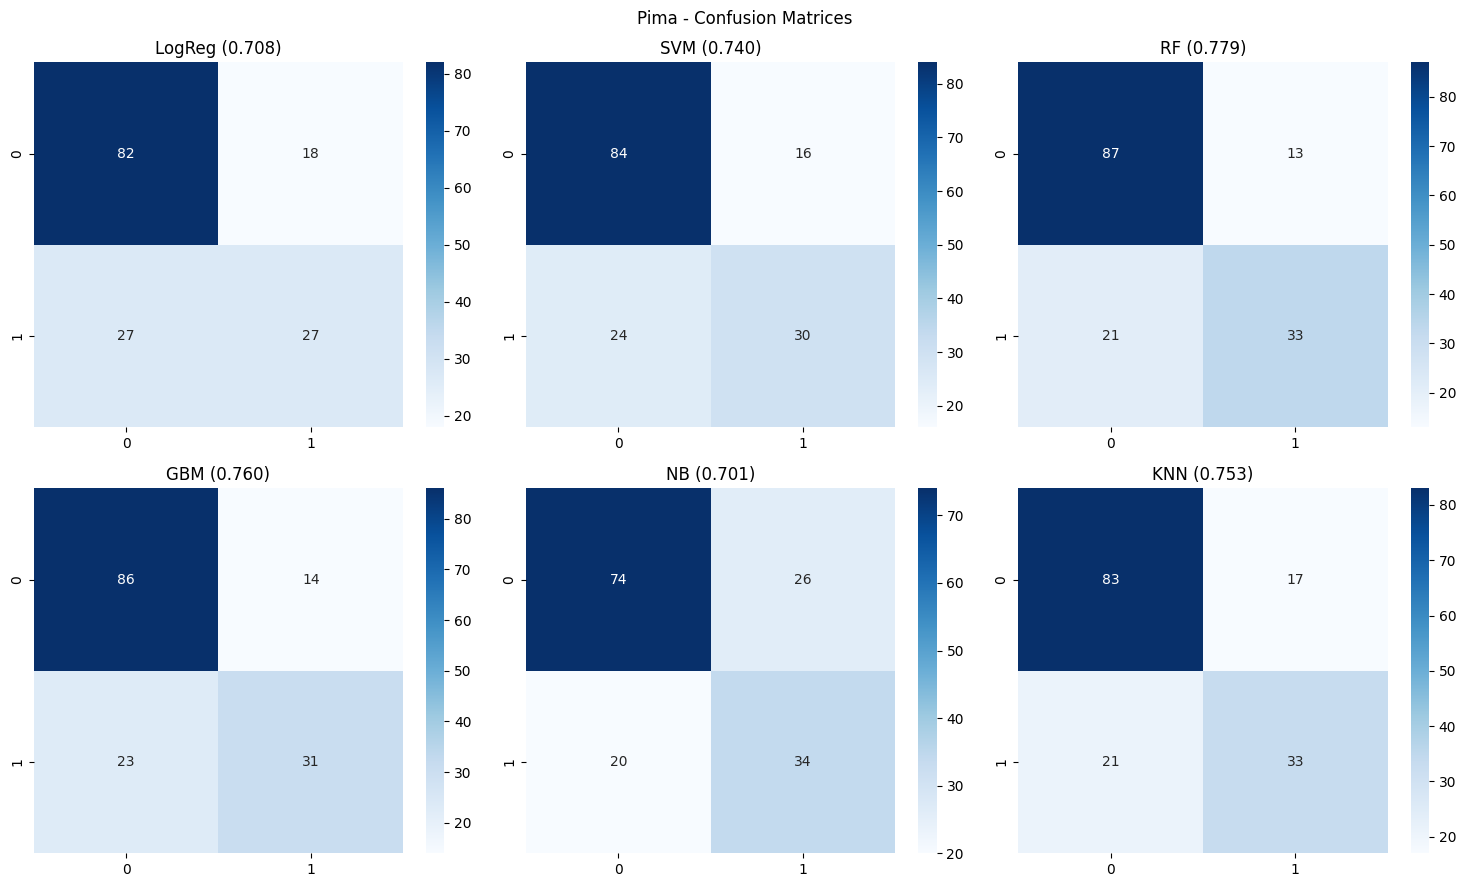

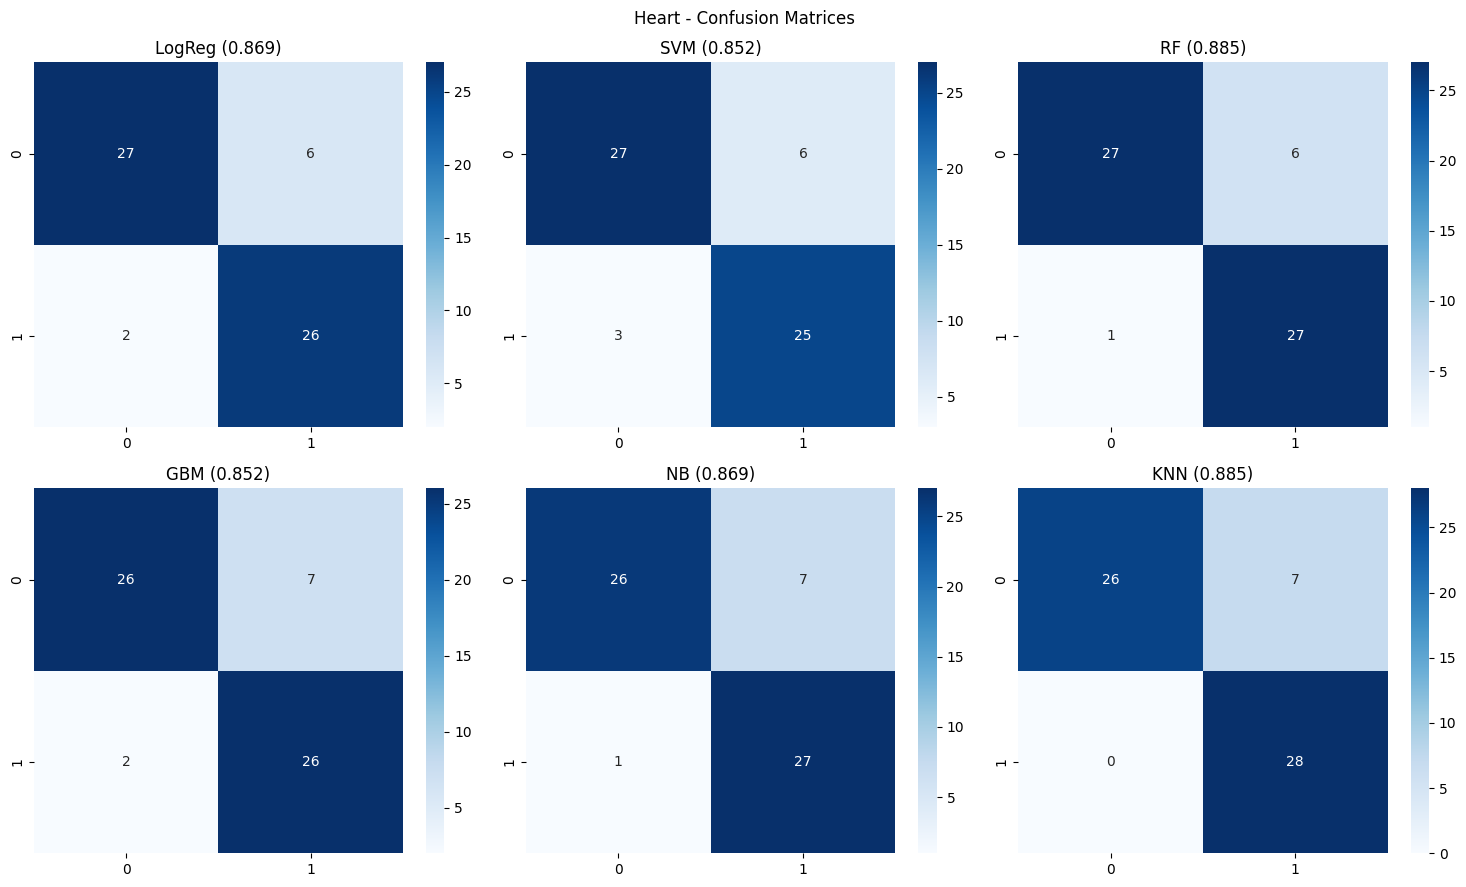

In [25]:
def plot_cms(res, y_te, title):
    fig, axs = plt.subplots(2, 3, figsize=(15, 9))
    for ax, (name, r) in zip(axs.ravel(), res.items()):
        cm = confusion_matrix(y_te, r['pred'])
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax)
        ax.set_title(f"{name} ({r['acc']:.3f})")
    plt.suptitle(title)
    plt.tight_layout()
    plt.show()

plot_cms(res1, y1_te, "Pima - Confusion Matrices")
plot_cms(res2, y2_te, "Heart - Confusion Matrices")

## 6. Уменьшение размерности

PCA Pima: explained variance = [0.29429594 0.18786978], sum=0.482


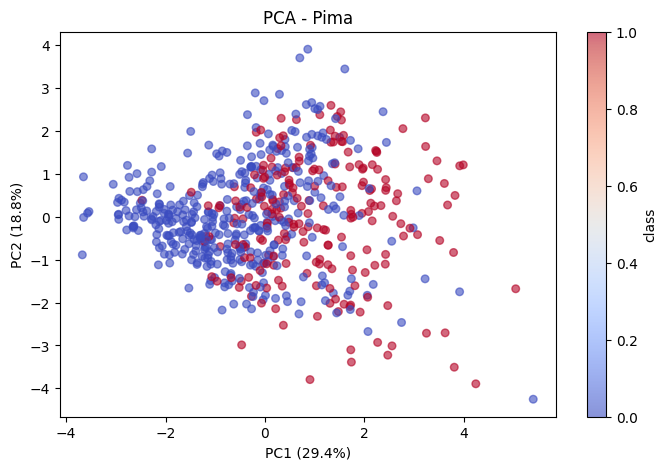

PCA Heart: explained variance = [0.2459193  0.12255207], sum=0.368


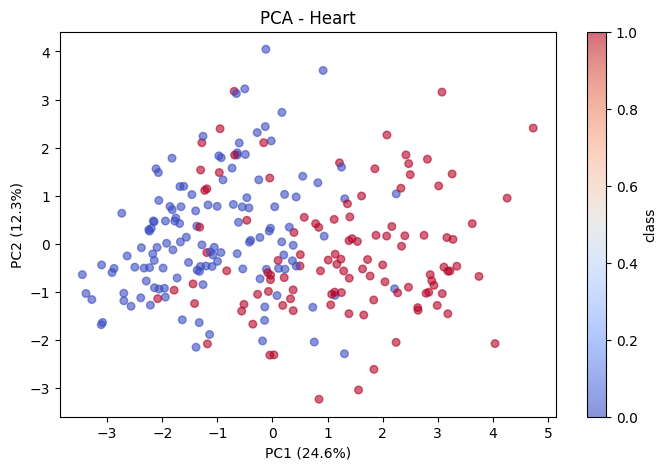

In [26]:
# PCA
def do_pca(X_tr, X_te, y_tr, title):
    pca = PCA(n_components=2)
    tr_pca = pca.fit_transform(X_tr)
    te_pca = pca.transform(X_te)

    print(f"PCA {title}: explained variance = {pca.explained_variance_ratio_}, sum={sum(pca.explained_variance_ratio_):.3f}")

    plt.figure(figsize=(8, 5))
    plt.scatter(tr_pca[:, 0], tr_pca[:, 1], c=y_tr, cmap='coolwarm', alpha=0.6, s=30)
    plt.colorbar(label='class')
    plt.title(f"PCA - {title}")
    plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)")
    plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)")
    plt.show()

    return tr_pca, te_pca

pca1_tr, pca1_te = do_pca(X1_tr_s, X1_te_s, y1_tr, "Pima")
pca2_tr, pca2_te = do_pca(X2_tr_s, X2_te_s, y2_tr, "Heart")

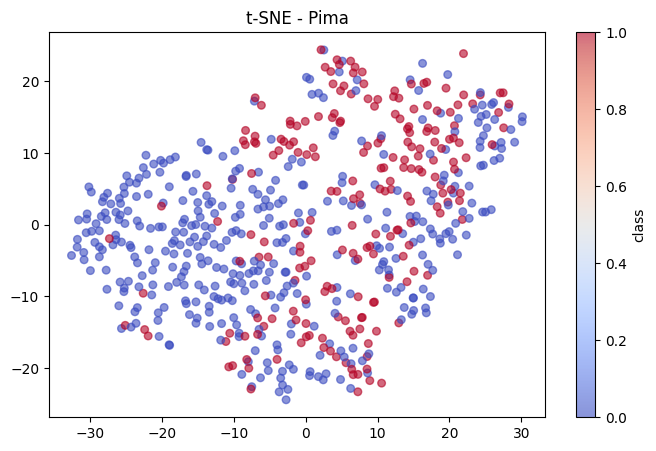

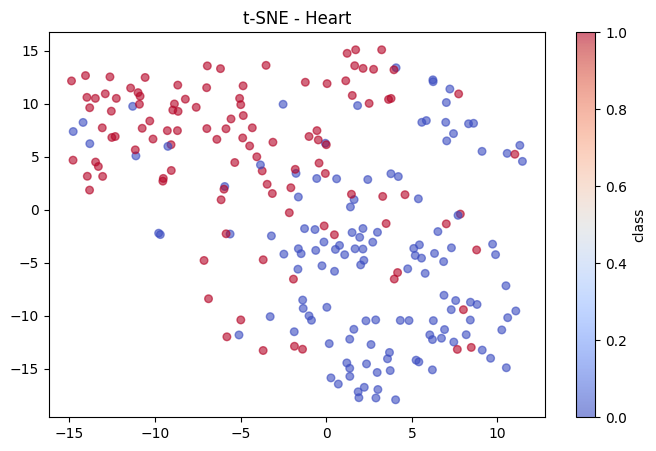

In [27]:
# t-SNE
for X_tr, y_tr, title in [(X1_tr_s, y1_tr, "Pima"), (X2_tr_s, y2_tr, "Heart")]:
    tsne = TSNE(n_components=2, random_state=42, perplexity=30)
    X_tsne = tsne.fit_transform(X_tr)

    plt.figure(figsize=(8, 5))
    plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=y_tr, cmap='coolwarm', alpha=0.6, s=30)
    plt.colorbar(label='class')
    plt.title(f"t-SNE - {title}")
    plt.show()

## LDA

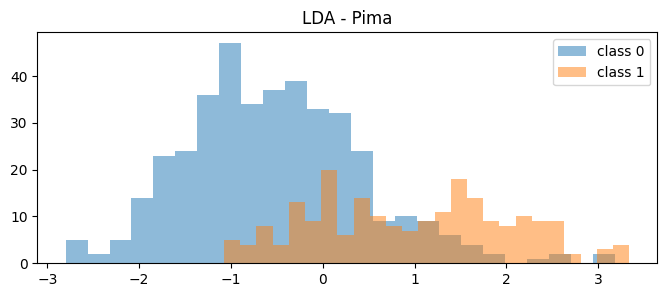

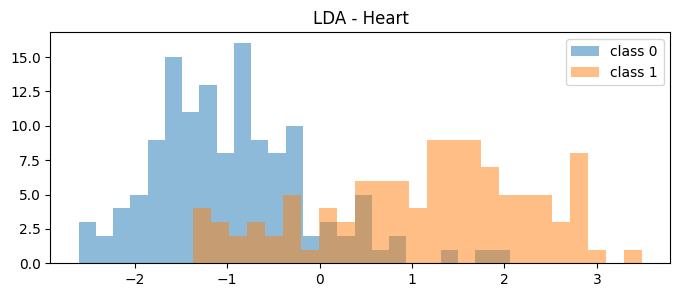

In [28]:
# LDA
def do_lda(X_tr, X_te, y_tr, title):
    lda = LDA(n_components=1)
    tr_lda = lda.fit_transform(X_tr, y_tr)
    te_lda = lda.transform(X_te)

    plt.figure(figsize=(8, 3))
    for c in [0, 1]:
        plt.hist(tr_lda[y_tr == c], bins=25, alpha=0.5, label=f'class {c}')
    plt.title(f"LDA - {title}")
    plt.legend()
    plt.show()

    return tr_lda, te_lda

lda1_tr, lda1_te = do_lda(X1_tr_s, X1_te_s, y1_tr, "Pima")
lda2_tr, lda2_te = do_lda(X2_tr_s, X2_te_s, y2_tr, "Heart")

## Модели на уменьшенных данных

In [29]:
def eval_reduced(X_tr, X_te, y_tr, y_te, method, dataset):
    print(f"\n{method} - {dataset} (dims={X_tr.shape[1]})")
    accs = {}
    for name in models:
        m = type(models[name])(**models[name].get_params())
        m.fit(X_tr, y_tr)
        acc = accuracy_score(y_te, m.predict(X_te))
        accs[name] = acc
        print(f"  {name}: {acc:.4f}")
    return accs

r1_pca = eval_reduced(pca1_tr, pca1_te, y1_tr, y1_te, "PCA", "Pima")
r1_lda = eval_reduced(lda1_tr, lda1_te, y1_tr, y1_te, "LDA", "Pima")
r2_pca = eval_reduced(pca2_tr, pca2_te, y2_tr, y2_te, "PCA", "Heart")
r2_lda = eval_reduced(lda2_tr, lda2_te, y2_tr, y2_te, "LDA", "Heart")


PCA - Pima (dims=2)
  LogReg: 0.7013
  SVM: 0.6948
  RF: 0.6688
  GBM: 0.6883
  NB: 0.6818
  KNN: 0.6753

LDA - Pima (dims=1)
  LogReg: 0.7013
  SVM: 0.7208
  RF: 0.6688
  GBM: 0.6753
  NB: 0.7013
  KNN: 0.7013

PCA - Heart (dims=2)
  LogReg: 0.8852
  SVM: 0.8197
  RF: 0.7705
  GBM: 0.7705
  NB: 0.8689
  KNN: 0.7869

LDA - Heart (dims=1)
  LogReg: 0.8525
  SVM: 0.8525
  RF: 0.7705
  GBM: 0.8033
  NB: 0.8525
  KNN: 0.8197


## 7. Бутстрэппинг

In [30]:
def bootstrap(X, y, model_cls, params, n_iter=100):
    scores = []
    for i in range(n_iter):
        Xb, yb = resample(X, y, random_state=i)
        Xtr, Xte, ytr, yte = train_test_split(Xb, yb, test_size=0.2, random_state=i)
        sc = StandardScaler()
        Xtr = sc.fit_transform(Xtr)
        Xte = sc.transform(Xte)
        m = model_cls(**params)
        m.fit(Xtr, ytr)
        scores.append(accuracy_score(yte, m.predict(Xte)))
    return np.array(scores)

model_params = {
    'LogReg': (LogisticRegression, {'max_iter': 1000, 'random_state': 42}),
    'SVM': (SVC, {'random_state': 42}),
    'RF': (RandomForestClassifier, {'n_estimators': 100, 'random_state': 42}),
    'GBM': (GradientBoostingClassifier, {'n_estimators': 100, 'random_state': 42}),
    'NB': (GaussianNB, {}),
    'KNN': (KNeighborsClassifier, {'n_neighbors': 5})
}

boot_res = {}
for ds_name, X, y in [("Pima", X1.values, y1.values), ("Heart", X2.values, y2.values)]:
    boot_res[ds_name] = {}
    print(f"\nBootstrap - {ds_name}")
    for mname, (cls, prms) in model_params.items():
        boot_res[ds_name][mname] = {}
        for n in [100, 250, 500]:
            sc = bootstrap(X, y, cls, prms, n_iter=n)
            boot_res[ds_name][mname][n] = sc
            print(f"  {mname} n={n}: {sc.mean():.4f} ± {sc.std():.4f}")


Bootstrap - Pima
  LogReg n=100: 0.7761 ± 0.0319
  LogReg n=250: 0.7736 ± 0.0335
  LogReg n=500: 0.7699 ± 0.0338
  SVM n=100: 0.8065 ± 0.0315
  SVM n=250: 0.8031 ± 0.0318
  SVM n=500: 0.7995 ± 0.0327
  RF n=100: 0.8934 ± 0.0240
  RF n=250: 0.8926 ± 0.0227
  RF n=500: 0.8900 ± 0.0254
  GBM n=100: 0.8622 ± 0.0314
  GBM n=250: 0.8609 ± 0.0294
  GBM n=500: 0.8588 ± 0.0294
  NB n=100: 0.7578 ± 0.0359
  NB n=250: 0.7554 ± 0.0342
  NB n=500: 0.7522 ± 0.0357
  KNN n=100: 0.7870 ± 0.0364
  KNN n=250: 0.7796 ± 0.0361
  KNN n=500: 0.7788 ± 0.0360

Bootstrap - Heart
  LogReg n=100: 0.8441 ± 0.0491
  LogReg n=250: 0.8399 ± 0.0497
  LogReg n=500: 0.8395 ± 0.0498
  SVM n=100: 0.8769 ± 0.0488
  SVM n=250: 0.8729 ± 0.0478
  SVM n=500: 0.8737 ± 0.0465
  RF n=100: 0.9139 ± 0.0350
  RF n=250: 0.9151 ± 0.0357
  RF n=500: 0.9155 ± 0.0358
  GBM n=100: 0.9036 ± 0.0382
  GBM n=250: 0.9017 ± 0.0379
  GBM n=500: 0.9018 ± 0.0388
  NB n=100: 0.8405 ± 0.0455
  NB n=250: 0.8380 ± 0.0475
  NB n=500: 0.8374 ± 0.0480


## Визуализация бутстрэпа

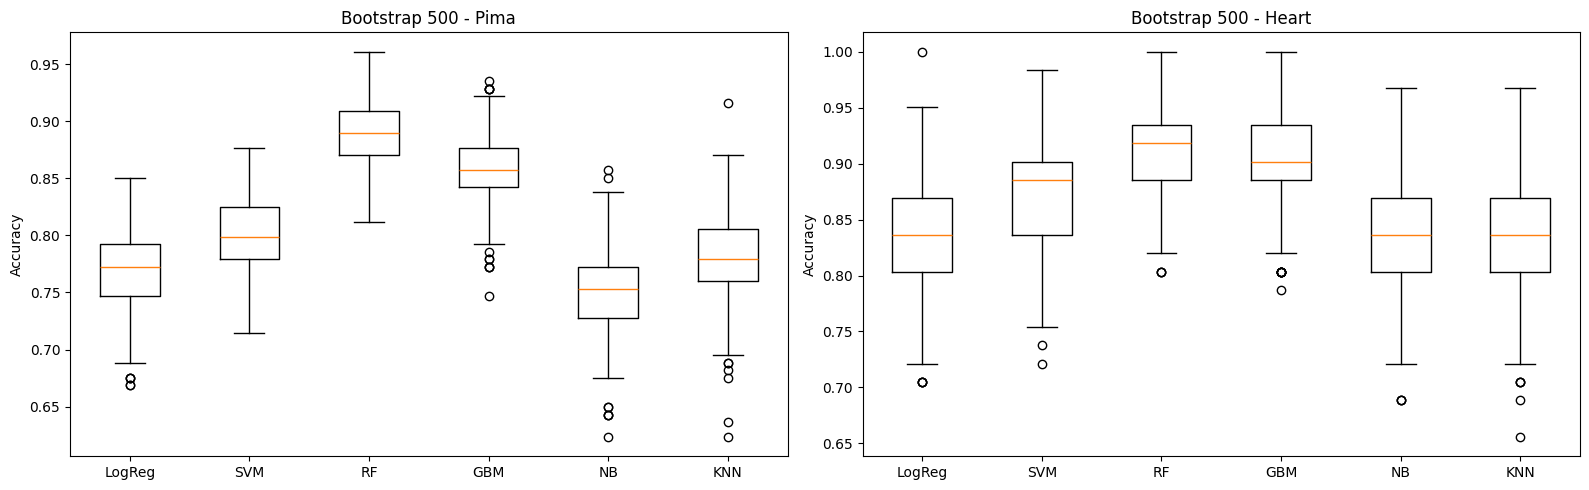

In [31]:
fig, axs = plt.subplots(1, 2, figsize=(16, 5))
for ax, ds in zip(axs, ["Pima", "Heart"]):
    data = [boot_res[ds][m][500] for m in model_params]
    ax.boxplot(data, labels=list(model_params.keys()))
    ax.set_title(f"Bootstrap 500 - {ds}")
    ax.set_ylabel("Accuracy")
plt.tight_layout()
plt.show()

## 8. Случайный поиск гиперпараметров

In [32]:
lr_params = {
    'C': uniform(0.01, 100),
    'penalty': ['l1', 'l2'],
    'solver': ['liblinear', 'saga'],
    'class_weight': [None, 'balanced'],
    'max_iter': [1000]
}

for name, Xtr, Xte, ytr, yte in [
    ("Pima", X1_tr_s, X1_te_s, y1_tr, y1_te),
    ("Heart", X2_tr_s, X2_te_s, y2_tr, y2_te)
]:
    rs = RandomizedSearchCV(LogisticRegression(random_state=42), lr_params,
                            n_iter=50, cv=5, scoring='accuracy',
                            random_state=42, n_jobs=-1)
    rs.fit(Xtr, ytr)
    yp = rs.predict(Xte)
    print(f"\n{name} - LogReg tuned")
    print(f"Best params: {rs.best_params_}")
    print(f"Best CV: {rs.best_score_:.4f}, Test: {accuracy_score(yte, yp):.4f}")
    print(classification_report(yte, yp))


Pima - LogReg tuned
Best params: {'C': np.float64(0.7166305219717406), 'class_weight': None, 'max_iter': 1000, 'penalty': 'l1', 'solver': 'liblinear'}
Best CV: 0.7834, Test: 0.7013
              precision    recall  f1-score   support

           0       0.75      0.81      0.78       100
           1       0.59      0.50      0.54        54

    accuracy                           0.70       154
   macro avg       0.67      0.66      0.66       154
weighted avg       0.69      0.70      0.70       154


Heart - LogReg tuned
Best params: {'C': np.float64(1.4179822715084456), 'class_weight': None, 'max_iter': 1000, 'penalty': 'l1', 'solver': 'saga'}
Best CV: 0.8304, Test: 0.8689
              precision    recall  f1-score   support

           0       0.93      0.82      0.87        33
           1       0.81      0.93      0.87        28

    accuracy                           0.87        61
   macro avg       0.87      0.87      0.87        61
weighted avg       0.88      0.87      0.

## 9. Итоговый отчёт

In [33]:
for ds, res_full, rpca, rlda, bres in [
    ("Pima", res1, r1_pca, r1_lda, boot_res["Pima"]),
    ("Heart", res2, r2_pca, r2_lda, boot_res["Heart"])
]:
    print(f"\n--- {ds} ---")
    rows = []
    for m in models:
        rows.append({
            'Model': m,
            'Full': f"{res_full[m]['acc']:.4f}",
            'PCA': f"{rpca[m]:.4f}",
            'LDA': f"{rlda[m]:.4f}",
            'Boot mean': f"{bres[m][500].mean():.4f}",
            'Boot std': f"{bres[m][500].std():.4f}"
        })
    print(pd.DataFrame(rows).to_string(index=False))


--- Pima ---
 Model   Full    PCA    LDA Boot mean Boot std
LogReg 0.7078 0.7013 0.7013    0.7699   0.0338
   SVM 0.7403 0.6948 0.7208    0.7995   0.0327
    RF 0.7792 0.6688 0.6688    0.8900   0.0254
   GBM 0.7597 0.6883 0.6753    0.8588   0.0294
    NB 0.7013 0.6818 0.7013    0.7522   0.0357
   KNN 0.7532 0.6753 0.7013    0.7788   0.0360

--- Heart ---
 Model   Full    PCA    LDA Boot mean Boot std
LogReg 0.8689 0.8852 0.8525    0.8395   0.0498
   SVM 0.8525 0.8197 0.8525    0.8737   0.0465
    RF 0.8852 0.7705 0.7705    0.9155   0.0358
   GBM 0.8525 0.7705 0.8033    0.9018   0.0388
    NB 0.8689 0.8689 0.8525    0.8374   0.0480
   KNN 0.8852 0.7869 0.8197    0.8385   0.0517


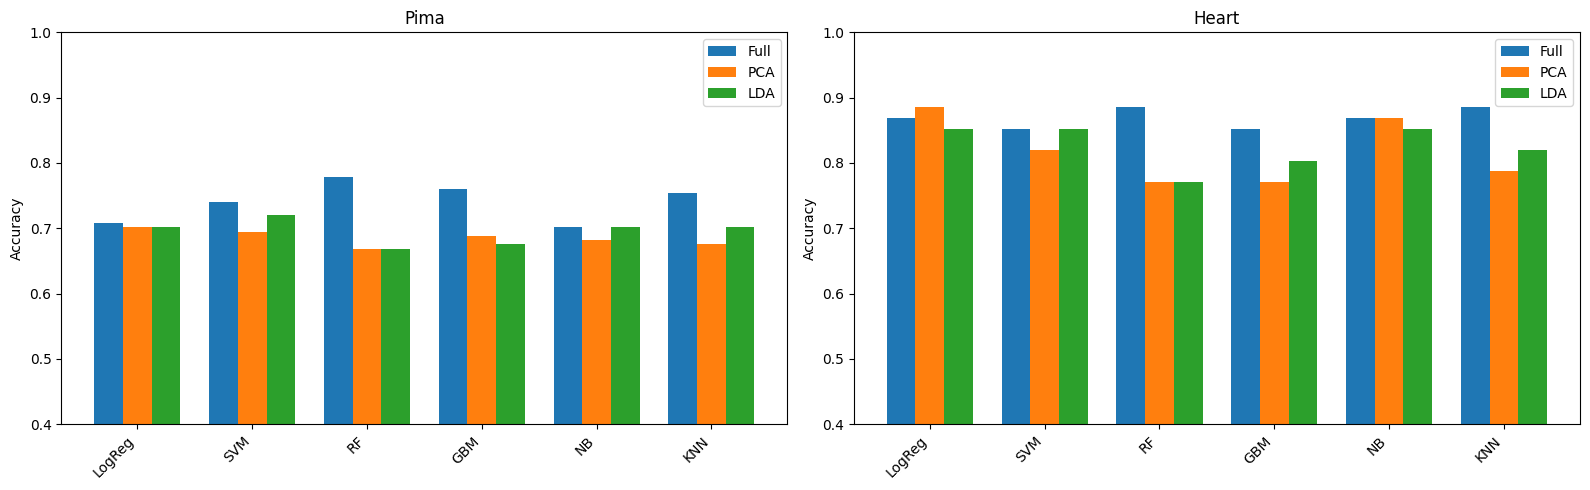

In [36]:
fig, axs = plt.subplots(1, 2, figsize=(16, 5))
for ax, ds, res_full, rpca, rlda in [
    (axs[0], "Pima", res1, r1_pca, r1_lda),
    (axs[1], "Heart", res2, r2_pca, r2_lda)
]:
    mnames = list(models.keys())
    x = np.arange(len(mnames))
    w = 0.25
    ax.bar(x - w, [res_full[m]['acc'] for m in mnames], w, label='Full')
    ax.bar(x, [rpca[m] for m in mnames], w, label='PCA')
    ax.bar(x + w, [rlda[m] for m in mnames], w, label='LDA')
    ax.set_xticks(x)
    ax.set_xticklabels(mnames, rotation=45, ha='right')
    ax.set_ylabel('Accuracy')
    ax.set_title(ds)
    ax.legend()
    ax.set_ylim(0.4, 1)
plt.tight_layout()
plt.show()

# Выводы

1. Лучшие модели:
  
    Pima: RF (0.779) и GBM (0.760), линейные модели заметно хуже (~0.70)
    На бутстрэпе лидерство у RF: 0.890 ± 0.025 - самый стабильный

    Heart: RF и KNN делят первое место (0.885), но по бутстрэпу
    RF надежнее (0.916 ± 0.036 vs 0.839 ± 0.052)

    В целом ансамблевые модели выигрывают на обоих датасетах

2. Уменьшение размерности:
   
    PCA и LDA ухудшают результаты большинства моделей
    Сильнее всего страдают ансамбли: RF на Pima просел с 0.779 до 0.669
    Исключение: PCA + LogReg на Heart улучшил точность (0.885 vs 0.869),
    видимо PCA убрал шум и помог линейной модели

    Вывод: для визуализации полезно, для классификации — чаще вредит

3. Гиперпараметры LogReg:

    Pima: C=0.72, L1, liblinear — сильная регуляризация + отбор признаков,
    но на тесте результат не улучшился (0.701 vs 0.708)

    Heart: C=1.42, L1, saga — близко к изначальной, точность та же (0.869)
   